# Scene Graph Task Generation:
In this notebook, we will show how to generate Scene Graph ImageQA test cases in Task-Me-Anything, including: `WhatObjectSceneGraphTaskGenerator`, `WhatAttributeSceneGraphTaskGenerator`, and `WhatRelationSceneGraphTaskGenerator`.

## Requirements

If you want to run this notebook, you need to add `..` to python package search path. You can do this by running the following command in the root directory of the repository:

In [1]:
import sys
sys.path.append("../..")

## Download Scene Graph
We use GQA version of Scene Graph, you can download it from the link: https://downloads.cs.stanford.edu/nlp/data/gqa/sceneGraphs.zip

## Using TaskGenerator to enumerate task plans and store them into local parquet file

* `TaskGenerator` is a class used to enumerate all the possible task plans from the source metadata, and generate VQA test cases based on the task plans. (e.g. `WhatGridTaskGenerator`)
* `TaskStore` is a class designed to handle the task plan generated by the task generator. The task store can output data in a pandas dataframe format.
  
In this notebook, instead of using a single type of generator, we will use multiple types of generators to generate test cases. So we introduce a new class `JointTaskGenerator`:
* `JointTaskGenerator` is a class to assemble multiple `TaskGenerator` into a joint task generator. 

After downloading the source data, we first create a `SceneGraphMetaData` object to load the Scene Graph metadata. Then you can first create a dict of TaskGenerator, and then pass it to `JointTaskGenerator` to create a joint task generator. This generator has the same interface as a single task generator, but it will generate tasks from all the task generators in the dict.

In [2]:
from tma.imageqa.scene_graph import *
from tma.base import JointTaskGenerator
from tma.imageqa.metadata import SceneGraphMetaData


path = '/home/zl20/uouo/UOUO/TaskMeAnything/data'  # the path to scene_graph folder
metadata = SceneGraphMetaData('../../annotations', scene_graph_folder=path)

generators = {
    'what object'              : WhatObjectSceneGraphTaskGenerator,
    'what attribute'             : WhatAttributeSceneGraphTaskGenerator,
    'what relation'          : WhatRelationSceneGraphTaskGenerator,
}
generator = JointTaskGenerator(metadata, generators)

In [3]:
!pwd

/home/zl20/uouo/UOUO/TaskMeAnything/demo/generate


Once you feed the metadata to the task generator, we can start to enumerate all the possible task plans by using `generator.enumerate_task_plans()` method. We also need to initialize `TaskStore` to store the task plans. When we initialize `TaskStore` with a `output_file`, it will save the task plans to a local parquet file without holding them in memory. After task plans enumeration, use `task_store.close()` method to make sure the parquet writer is appropriately closed. 

Note that `buffer_size` is the maximum number of task plans to hold in memory before writing to the parquet file which save in disk. If your memory is limited, you can set a smaller buffer_size to avoid memory overflow. Typically, `1e6` is a good choice for server which has less than 32GB memory.


In [ ]:
from tma.task_store import TaskStore

save_path = '/home/zl20/uouo/UOUO/TaskMeAnything/sg.parquet'  # path to save task plans to a parquet
task_store = TaskStore(output_file=save_path, schema=generator.schema, buffer_size=1e6)
generator.enumerate_task_plans(task_store)
task_store.close()

Writing to /home/zl20/uouo/UOUO/TaskMeAnything/sg.parquet
number of scene graphs: 74942


enumerating [what object] task: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 74942/74942 [25:40<00:00, 48.65it/s]


Generated [2658665] what object tasks


enumerating [what attribute] task:  45%|████████████████████████████████████████████████████████████████████████████▉                                                                                                | 33353/74942 [51:48<04:20, 159.70it/s]IOPub message rate exceeded.
The Jupyter server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--ServerApp.iopub_msg_rate_limit`.

Current values:
ServerApp.iopub_msg_rate_limit=1000.0 (msgs/sec)
ServerApp.rate_limit_window=3.0 (secs)

enumerating [what relation] task:  20%|██████████████████████████████████▉                                                                                                                                        | 15335/74942 [1:47:41<6:01:44,  2.75it/s]

The `JointTaskGenerator` also maintains a `stats` attribute, which is a dictionary that records the number of tasks generated by each task generator.

In [5]:
generator.stats

{'what object': 2658665, 'what attribute': 3019207, 'what relation': 176634}

In [6]:
import pandas as pd
import pyarrow.parquet as pq
from IPython.display import display

df = pd.read_parquet(save_path)
display(df.head())


,task type,object,subgraph,scene graph id,answers,attribute type,attribute value,relation,source object,target object,source subgraph,target subgraph
0,what object,banana,"{""attributes"": [""small"", ""yellow""], ""adjacent_...",2386621,[banana],None,None,None,None,None,None,None
1,what object,banana,"{""attributes"": [""small"", ""yellow""], ""adjacent_...",2386621,[banana],None,None,None,None,None,None,None
2,what object,banana,"{""attributes"": [""small"", ""yellow""], ""adjacent_...",2386621,[banana],None,None,None,None,None,None,None
3,what object,banana,"{""attributes"": [""small"", ""yellow""], ""adjacent_...",2386621,[banana],None,None,None,None,None,None,None
4,what object,banana,"{""attributes"": [""small""], ""adjacent_objects"": ...",2386621,[banana],None,None,None,None,None,None,None


In [16]:
#shuffle dataframe
def random_sample(df, num_rows = 5000):
    df_shuffle = df.sample(n=num_rows).reset_index(drop=True)
    return df_shuffle

df_shuffle = random_sample(df, 5000)
#df_shuffle.head()

def random_sample_with_shift(df, num_rows = 5000):
    df_shuffle1 = df[df["task type"] == "what object"].sample(n=int(num_rows/3)).reset_index(drop=True)
    df_shuffle2 = df[df["task type"] == "what attribute"].sample(n=int(num_rows/3)).reset_index(drop=True)
    df_shuffle3 = df[df["task type"] == "what relation"].sample(n=int(num_rows/3)).reset_index(drop=True)

    return pd.concat([df_shuffle1, df_shuffle2, df_shuffle3], ignore_index=True)

df_shuffle = random_sample_with_shift(df, 5000)
df_shuffle.head()

,task type,object,subgraph,scene graph id,answers,attribute type,attribute value,relation,source object,target object,source subgraph,target subgraph
0,what object,head,"{""attributes"": [""bald"", ""caucasian""], ""adjacen...",2410029,[head],None,None,None,None,None,None,None
1,what object,wall,"{""attributes"": [], ""adjacent_objects"": [{""obje...",2367252,[wall],None,None,None,None,None,None,None
2,what object,trunk,"{""attributes"": [], ""adjacent_objects"": [{""obje...",2316963,"[bench, leaves, leg, person, tree, trunk]",None,None,None,None,None,None,None
3,what object,ear,"{""attributes"": [""round""], ""adjacent_objects"": ...",2319983,[ear],None,None,None,None,None,None,None
4,what object,boot,"{""attributes"": [""empty"", ""red""], ""adjacent_obj...",2349678,[boot],None,None,None,None,None,None,None


scene graphs: object
tree            79309
man             78668
elephant        58315
building        52883
grass           49868
                ...  
cigarettes          1
swamp               1
hospital            1
pizza pie           1
potato salad        1
Name: count, Length: 1402, dtype: int64


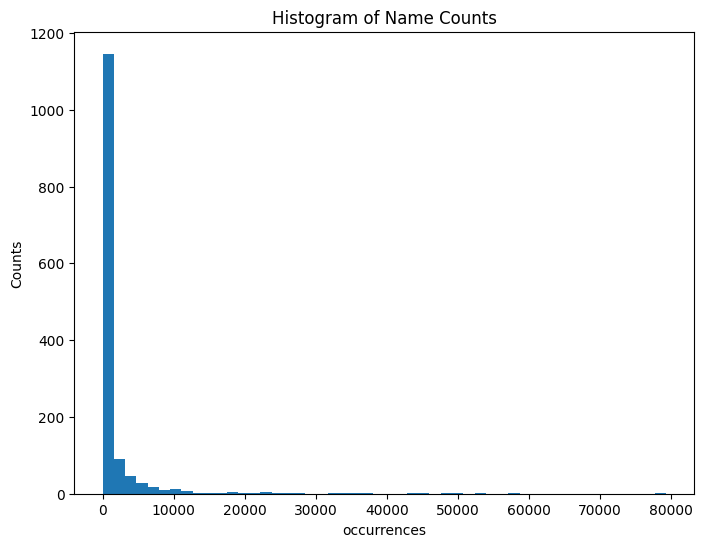

In [13]:
print("scene graphs:", df['object'].value_counts())

plt.figure(figsize=(8, 6))
plt.hist(df['object'].value_counts().values, bins=50)
plt.xlabel('occurrences')
plt.ylabel('Counts')
plt.title('Histogram of Name Counts')
plt.show()

{'attributes': ['small', 'yellow'], 'adjacent_objects': [{'object': 'straw', 'attributes': ['white'], 'relation': ['to the right of', 1]}]}


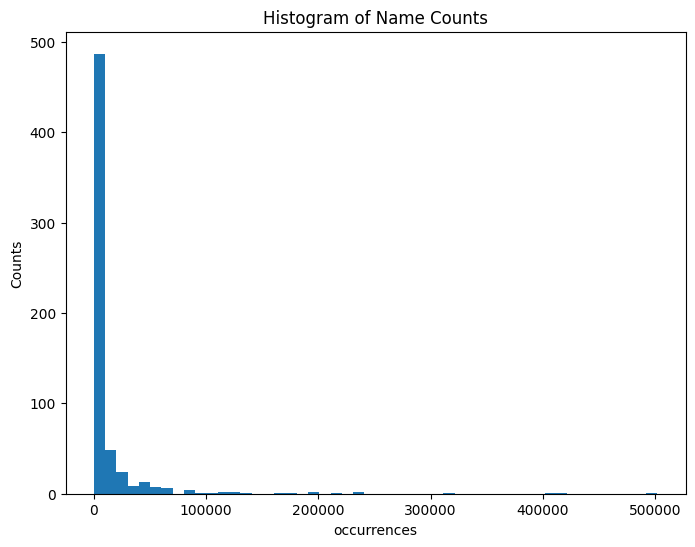

In [9]:
import matplotlib.pyplot as plt
import json
from collections import defaultdict
name_counts = df[df['task type'] == 'what attribute']['subgraph'].value_counts()
occurrences = defaultdict(int)
for i in range(len(df)):
    try:
        for j in json.loads(df['subgraph'][i])['attributes']:
            occurrences[j] += 1
    except:
        pass

        
print(json.loads(df['subgraph'][0]))



# Plot a histogram
plt.figure(figsize=(8, 6))
plt.hist(occurrences.values(), bins=50)
plt.xlabel('occurrences')
plt.ylabel('Counts')
plt.title('Histogram of Name Counts')
plt.show()

In [45]:
import pandas as pd
import pyarrow.parquet as pq
from tma.task_store import get_pd_schema
from tqdm import tqdm
from pprint import pprint # use pprint to print the task
from IPython.display import display

# types = ['what object', 'what attribute', 'what relation'] # select the types of task plans you want
# filters = [[('task type', '==', t)] for t in types]

task_type = 'what attribute'
filter = [('task type', '==', task_type)]
df = pq.read_table(save_path, filters=filter).to_pandas().astype(get_pd_schema(generator.schema))

print('num of unique target objects:')
print(len(set(df['target object'])))
print('num of unique source objects:')
print(len(set(df['source object'])))

grouped_counts = df.groupby(['source object', 'target object']).size()

average_count = grouped_counts.mean()

median_count = grouped_counts.median()

# print("Counts of samples per group:")
# print(grouped_counts)

print("Average number of samples per group:")
print(average_count)

print("\Median number of samples per group:")
print(median_count)

sorted_counts = grouped_counts.sort_values(ascending=False)
print("Counts of samples per group > 25, ordered by most frequent:")
print(len(sorted_counts[sorted_counts > 25]))

num of unique target objects:
1
num of unique source objects:
1
Average number of samples per group:
nan
\Median number of samples per group:
nan
Counts of samples per group > 25, ordered by most frequent:
0


num of sample has relaton: what relation, source object: hair: 1


,task type,object,subgraph,scene graph id,answers,attribute type,attribute value,relation,source object,target object,source subgraph,target subgraph
0,what relation,<NA>,<NA>,2379672,[to the right of],<NA>,<NA>,to the right of,curtain,hair,"{""attributes"": [""floral"", ""flowered""], ""adjace...","{""attributes"": [""long""], ""adjacent_objects"": [..."


{'answer': 'to the right of',
 'image': <PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=500x333 at 0x7F31DB2A8940>,
 'options': ['to the right of', 'scattered on', 'next to', 'pouring'],
 'question': 'What is the relation from the floral and flowered object, which '
             'the black cat is to the left of, to the long object, which the '
             'black and sitting cat is to the left of?',
 'scene_graph_id': '2379672',
 'task_plan': 'task type: what relation\n'
              'relation: to the right of\n'
              'source object: curtain\n'
              'target object: hair'}


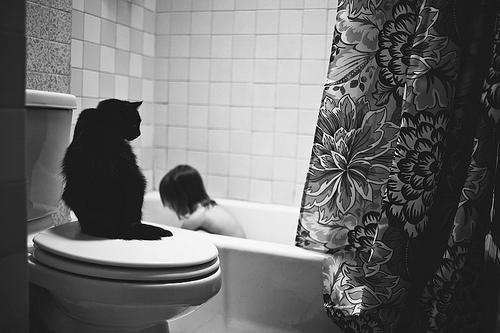

In [14]:
import pandas as pd
import pyarrow.parquet as pq
from tma.task_store import get_pd_schema
from tqdm import tqdm
from pprint import pprint # use pprint to print the task
from IPython.display import display

# types = ['what object', 'what attribute', 'what relation'] # select the types of task plans you want
# filters = [[('task type', '==', t)] for t in types]

pool = []
sample_num = 100
idx = 0
task_type = 'what relation'
src_obj = 'curtain'
tar_obj = 'hair'
filter = [('task type', '==', task_type), ('source object', '==', src_obj), ('target object', '==', tar_obj)]
df = pq.read_table(save_path, filters=filter).to_pandas().astype(get_pd_schema(generator.schema))
print(f'num of sample has relaton: {task_type}, source object: {tar_obj}: {len(df)}')
display(df.head())
df.iloc[idx].dropna()
task = generator.generate(df.iloc[idx].dropna().to_dict(), return_data=True)
pprint(task)
display(task['image'])
# if len(df) > sample_num:
#     df = df.sample(sample_num)
# pool.append(df)

In [15]:
len(pool[0])

IndexError: list index out of range

## Sample task plans from local parquet file and generate VQA test cases

We can Load the task plans from the local parquet file to a Pandas dataframe by using `pq.read_table(save_path, filters=f).to_pandas().astype(get_pd_schema(generator.schema)` method. After that, we can use `generator.generate()` method to generate VQA test cases based on the task plan.

  0%|                                                                                                                                                                                                                                 | 0/3 [00:00<?, ?it/s]

{'answer': 'table',
 'image': <PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=500x400 at 0x7F31BA6B7A90>,
 'options': ['table', 'radiator', 'almond', 'jar'],
 'question': 'What is the object that the light colored, square, and white '
             'plate is on?',
 'scene_graph_id': '2375361',
 'task_plan': 'task type: what object\nobject: table'}


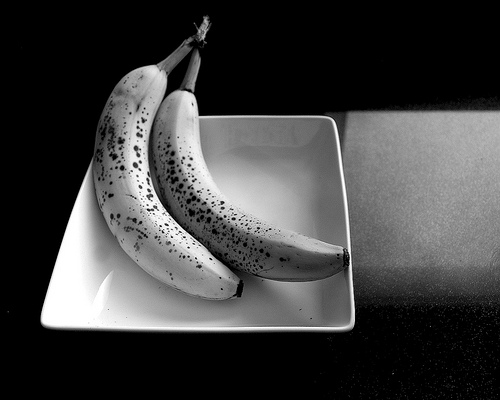

 33%|████████████████████████████████████████████████████████████████████████▎                                                                                                                                                | 1/3 [00:00<00:01,  1.71it/s]

{'answer': 'square',
 'image': <PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=500x333 at 0x7F31B05205E0>,
 'options': ['square', 'rounded', 'curvy', 'oblong'],
 'question': 'What is the shape of the white object that the little and small '
             'sandwiches is on?',
 'scene_graph_id': '2343566',
 'task_plan': 'task type: what attribute\n'
              'attribute type: shape\n'
              'attribute value: square'}


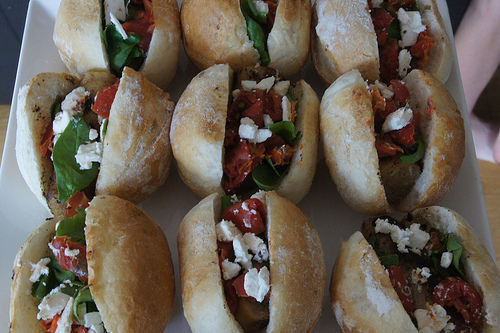

 67%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▋                                                                        | 2/3 [00:01<00:00,  1.81it/s]

{'answer': 'to the left of',
 'image': <PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=500x333 at 0x7F31B0522E80>,
 'options': ['to the left of', 'coming from', 'walking past', 'of'],
 'question': 'What is the relation from the happy object, which is to the left '
             'of the smiling and young boy, to the blue object, which the '
             'smiling and young girl is to the right of?',
 'scene_graph_id': '2394852',
 'task_plan': 'task type: what relation\n'
              'relation: to the left of\n'
              'source object: woman\n'
              'target object: eye'}


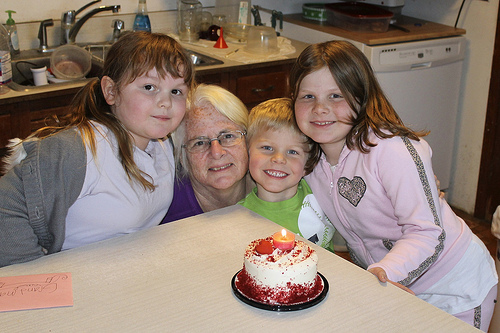

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 3/3 [00:01<00:00,  2.31it/s]


In [17]:
import pandas as pd
import pyarrow.parquet as pq
from tma.task_store import get_pd_schema
from tqdm import tqdm
from pprint import pprint # use pprint to print the task

types = ['what object', 'what attribute', 'what relation'] # select the types of task plans you want
filters = [[('task type', '==', t)] for t in types]

save_path = '/home/zl20/uouo/UOUO/TaskMeAnything/sg.parquet'
pool = []
sample_num = 100
idx = 35
for filter in tqdm(filters):
    df = pq.read_table(save_path, filters=filter).to_pandas().astype(get_pd_schema(generator.schema))
    df.iloc[idx].dropna()
    idx += 20
    task = generator.generate(df.iloc[idx].dropna().to_dict(), return_data=True)
    pprint(task)
    display(task['image'])

    if len(df) > sample_num:
        df = df.sample(sample_num)
    pool.append(df)

Above is 3 VQA test cases generated from different types of generators. 

The dataframe below shows the example task plans we used to generated test instances:

The values start with "Q" in the `target category`, `reference category` columns of the returned dataframe is the QID of the category, which corresponds to a Wikidata entry (eg,  `Q11422` corresponds to https://www.wikidata.org/wiki/Q11422).

Note that different question types have different schema, For example, for "what" type question, we don't need count, so the `count` column is `<NA>`.

In [9]:
example_df = pd.concat(pool)
example_df

,task type,object,subgraph,scene graph id,answers,attribute type,attribute value,relation,source object,target object,source subgraph,target subgraph
9164,what object,stone,"{""attributes"": [""clumped"", ""gray""], ""adjacent_...",2389400,[stone],<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>
21027,what object,tree,"{""attributes"": [], ""adjacent_objects"": [{""obje...",2392431,[tree],<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>
10001,what object,tray,"{""attributes"": [""brown"", ""filled"", ""wicker""], ...",2409141,[tray],<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>
24172,what object,woman,"{""attributes"": [], ""adjacent_objects"": [{""obje...",2336142,"[arm, woman]",<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>
9781,what object,bread,"{""attributes"": [""brown""], ""adjacent_objects"": ...",2404263,[bread],<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>
...,...,...,...,...,...,...,...,...,...,...,...,...
6465,what relation,<NA>,<NA>,2400072,[on],<NA>,<NA>,on,poster,pole,"{""attributes"": [""purple""], ""adjacent_objects"":...","{""attributes"": [""wood""], ""adjacent_objects"": [..."
7856,what relation,<NA>,<NA>,2376382,[to the left of],<NA>,<NA>,to the left of,box,clock,"{""attributes"": [""green""], ""adjacent_objects"": ...","{""attributes"": [""round""], ""adjacent_objects"": ..."
20336,what relation,<NA>,<NA>,2382835,[looking at],<NA>,<NA>,looking at,person,lake,"{""attributes"": [""skiing""], ""adjacent_objects"":...","{""attributes"": [""reflective""], ""adjacent_objec..."
16280,what relation,<NA>,<NA>,2381855,[to the right of],<NA>,<NA>,to the right of,window,glass,"{""attributes"": [""white""], ""adjacent_objects"": ...","{""attributes"": [], ""adjacent_objects"": [{""obje..."


In [ ]:
import random
import math
import numpy as np

def generate_queries(df, num_queries, num_unique_queries, zipf_scaling=1):
    """
        Generate a workload with *num_queries* queries, out of which there are *num_unique_queries* unique query templates.
        The frequency of templates follow a zipf distribion, i.e., the ith query template is bootstraped with probability
        1/(i^zipf_scaling) (normalized).
    """
    np.random.seed(10)
    random.seed(10)

    # 1. sample num_unique_queries rows in the dataframe to bootstrap from
    bootstrap_rows = random.sample([i for i in range(len(df))], num_unique_queries)
    print("bootstrapped rows")

    # 2. compute normalized frequencies
    probs = [math.pow(1 / (i + 1), zipf_scaling) for i in range(len(bootstrap_rows))]
    sum_probs = sum(probs)
    probs = [i / sum_probs for i in probs]
    print("computed frequencies")

    # 3. sample rows
    new_df = pd.DataFrame(columns=df.columns)
    for i in range(num_queries):
        if i % 1000 == 0:
            print("rows:", i)
        row = df.iloc[np.random.choice(bootstrap_rows, size=1, replace=False, p=probs)].iloc[0]
        new_df.loc[i] = row.values

    return new_df

new_df = generate_queries(df, 100000, 2500)
print(new_df.head())

In [ ]:
# workload shift
